Corrected class distribution comparison:
Class                                    OBIA px   OBIA %      RF px     RF %
Bare and Urban Territories           131,733,991    4.29%     80,163    7.58%
Coniferous Forest                   2,162,182,247   70.38%    383,074   36.21%
Deciduous Forest                               0    0.00%    299,771   28.34%
Field/Agriculture                    778,083,762   25.33%    294,802   27.87%


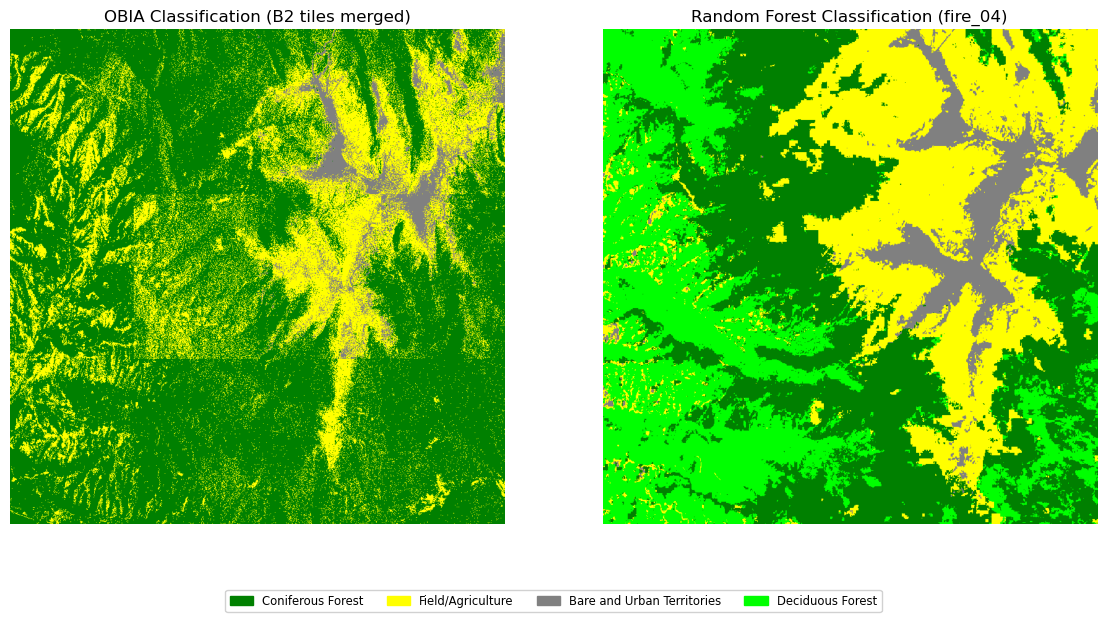

Comparison PNG saved to D:\data\master_thesis\exports\object_classification_results\B_files_combined\obia_vs_rf_comparison.png

Pixel‑wise RGB correlation (800×800 resized images):
  Red:      r = 0.2451  (p = 0.0000)
  Green:    r = 0.0520  (p = 0.0000)
  Blue:     r = 0.1663  (p = 0.0000)
  Grayscale: r = 0.2615  (p = 0.0000)

Corrected CSV saved to D:\data\master_thesis\exports\object_classification_results\B_files_combined\correlation_statistics.csv


In [3]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from PIL import Image
from scipy.stats import pearsonr

# ── File paths ──────────────────────────────────────────────────────────
# OBIA mosaic PNG and its class statistics (from the previous script)
# PNG мозайка от OBIA и нейните статистики (от предишния скрипт)
obia_png = r"D:\data\master_thesis\exports\object_classification_results\B_files_combined\B2_merged_mosaic.png"
obia_stats_csv = r"D:\data\master_thesis\exports\object_classification_results\B_files_combined\class_statistics.csv"

# Random Forest classification GeoTIFF and its statistics (best classifier)
# Класификационен GeoTIFF от Random Forest и неговите статистики (най-добър класификатор)
rf_tif   = r"D:\data\master_thesis\exports\sentinel2_fire_images\classification_report\best_classifier\fire_04_random_forest_classification.tif"
rf_csv   = r"D:\data\master_thesis\exports\sentinel2_fire_images\classification_report\best_classifier\fire_04_classification_statistics.csv"

# Output directory for comparison results
# Изходна директория за резултатите от сравнението
out_dir  = r"D:\data\master_thesis\exports\object_classification_results\B_files_combined"

# ── Settings ────────────────────────────────────────────────────────────
# Target size for the side‑by‑side visual comparison
# Целеви размер за паралелното визуално сравнение
TARGET_SIZE = (800, 800)   # for the side‑by‑side PNG / за паралелното PNG

# ── Colour map (canonical names → RGB) ───────────────────────────────────
# Defines colours for each land cover class (must match the classes in both maps)
# Задава цветове за всеки клас земно покритие (трябва да съвпадат с класовете в двете карти)
colour_map = {
    'Coniferous Forest':            (  0, 128,   0),   # dark green / тъмнозелено
    'Field/Agriculture':            (255, 255,   0),   # yellow / жълто
    'Bare and Urban Territories':   (128, 128, 128),   # gray / сиво
    'Deciduous Forest':             (  0, 255,   0),   # green / зелено
}
fallback_colour = (200, 200, 200)

# ── Mapping from OBIA raw names to canonical names ──────────────────────
# OBIA uses non‑standard class names (e.g. 'coniferousforestdrawn'); map them to canonical ones.
# OBIA използва нестандартни имена на класове (напр. 'coniferousforestdrawn'); преобразува ги в канонични.
obia_name_mapping = {
    'coniferousforestdrawn':            'Coniferous Forest',
    'fieldagriculturedrawn':            'Field/Agriculture',
    'urbanbuiltupbareterritoriesdrawn': 'Bare and Urban Territories',
    # add others if present (e.g. 'deciduousforestdrawn' if OBIA ever had it)
    # добавете други, ако ги има (напр. 'deciduousforestdrawn' ако OBIA някога е имала)
}

# ── 1. Load OBIA statistics (original pixel counts) ─────────────────────
# Read the raw pixel counts from the OBIA class statistics CSV.
# Чете суровите бройки пиксели от CSV файла със статистики на OBIA.
obia_counts_raw = {}
with open(obia_stats_csv, mode='r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)  # skip header / пропуска заглавния ред
    for row in reader:
        name = row[0].strip()
        count = int(row[1])
        obia_counts_raw[name] = count

# Map to canonical names and sum (in case multiple raw names map to the same canonical class)
# Преобразува в канонични имена и сумира (в случай че няколко сурови имена се отнасят към един и същ каноничен клас)
obia_counts = {}
for raw_name, count in obia_counts_raw.items():
    canonical = obia_name_mapping.get(raw_name.lower(), raw_name)   # fallback to original if unknown / резервно – оригинално, ако е непознато
    obia_counts[canonical] = obia_counts.get(canonical, 0) + count

obia_total = sum(obia_counts.values())

# ── 2. Load RF statistics from its CSV ──────────────────────────────────
# Read the Random Forest class statistics.
# Чете статистиките на Random Forest.
rf_counts = {}
with open(rf_csv, mode='r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)  # skip header / пропуска заглавния ред
    for row in reader:
        # Columns: class_id, class_name, pixel_count, percentage
        # Колони: class_id, class_name, pixel_count, percentage
        name = row[1].strip()
        count = int(row[2])
        rf_counts[name] = count

rf_total = sum(rf_counts.values())

# ── 3. Build unified class list and compute percentages ─────────────────
# Combine all unique classes from both datasets and calculate their relative abundance.
# Обединява всички уникални класове от двата набора данни и изчислява относителната им площ.
all_classes = sorted(set(list(obia_counts.keys()) + list(rf_counts.keys())))
distribution_data = []
for cls in all_classes:
    obia_cnt = obia_counts.get(cls, 0)
    rf_cnt = rf_counts.get(cls, 0)
    obia_pct = (obia_cnt / obia_total * 100) if obia_total > 0 else 0.0
    rf_pct = (rf_cnt / rf_total * 100) if rf_total > 0 else 0.0
    distribution_data.append([cls, obia_cnt, f"{obia_pct:.2f}%", rf_cnt, f"{rf_pct:.2f}%"])

# Print distribution / Отпечатва разпределението
print("Corrected class distribution comparison:")
print(f"{'Class':<35} {'OBIA px':>12} {'OBIA %':>8} {'RF px':>10} {'RF %':>8}")
for row in distribution_data:
    print(f"{row[0]:<35} {row[1]:>12,} {row[2]:>8} {row[3]:>10,} {row[4]:>8}")

# ── 4. Build side‑by‑side RGB images (for visual comparison and correlation) ──
# OBIA already coloured PNG / OBIA вече е оцветено PNG
obia_pil = Image.open(obia_png)
obia_resized = obia_pil.resize(TARGET_SIZE, Image.NEAREST)
obia_arr = np.array(obia_resized)   # uint8 RGB

# RF classification to RGB (using canonical colour map)
# Класификация на Random Forest в RGB (използва каноничната цветова карта)
with rasterio.open(rf_tif) as src:
    rf_raw = src.read(1)
    nodata = src.nodata

# Build colour mapping from RF CSV (class_id -> canonical name -> colour)
# Изгражда цветово съответствие от CSV на RF (class_id -> канонично име -> цвят)
class_id_to_canonical = {}
with open(rf_csv, mode='r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        cid = int(row[0])
        name = row[1].strip()
        class_id_to_canonical[cid] = name

rows, cols = rf_raw.shape
rf_rgb = np.zeros((rows, cols, 3), dtype=np.uint8)
valid_mask = (rf_raw != nodata) if nodata is not None else np.ones_like(rf_raw, dtype=bool)

for cid, canonical_name in class_id_to_canonical.items():
    colour = colour_map.get(canonical_name, fallback_colour)
    rf_rgb[(rf_raw == cid) & valid_mask] = colour

rf_pil = Image.fromarray(rf_rgb)
rf_resized = rf_pil.resize(TARGET_SIZE, Image.NEAREST)
rf_arr = np.array(rf_resized)

# ── 5. Save side‑by‑side PNG ────────────────────────────────────────────
# Plot the two classification maps next to each other and save.
# Показва двете класификационни карти една до друга и ги записва.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(obia_arr)
ax1.set_title("OBIA Classification (B2 tiles merged)", fontsize=12)
ax1.axis('off')
ax2.imshow(rf_arr)
ax2.set_title("Random Forest Classification (fire_04)", fontsize=12)
ax2.axis('off')

legend_handles = []
for canonical_name, col in colour_map.items():
    legend_handles.append(mpatches.Patch(color=np.array(col)/255.0, label=canonical_name))
if nodata is not None:
    legend_handles.append(mpatches.Patch(color='black', label='NoData'))

fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           framealpha=0.9, fontsize='small')
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
comparison_png = f"{out_dir}\\obia_vs_rf_comparison.png"
fig.savefig(comparison_png, bbox_inches='tight', dpi=150)
plt.show()
print(f"Comparison PNG saved to {comparison_png}")

# ── 6. Pixel‑wise RGB correlation ───────────────────────────────────────
# Compute Pearson correlation between corresponding colour channels.
# Изчислява корелация на Пиърсън между съответните цветови канали.
obia_r = obia_arr[:,:,0].ravel()
obia_g = obia_arr[:,:,1].ravel()
obia_b = obia_arr[:,:,2].ravel()
rf_r = rf_arr[:,:,0].ravel()
rf_g = rf_arr[:,:,1].ravel()
rf_b = rf_arr[:,:,2].ravel()

corr_r, p_r = pearsonr(obia_r, rf_r)
corr_g, p_g = pearsonr(obia_g, rf_g)
corr_b, p_b = pearsonr(obia_b, rf_b)
obia_gray = np.mean(obia_arr, axis=2).ravel()
rf_gray = np.mean(rf_arr, axis=2).ravel()
corr_gray, p_gray = pearsonr(obia_gray, rf_gray)

print("\nPixel‑wise RGB correlation (800×800 resized images):")
print(f"  Red:      r = {corr_r:.4f}  (p = {p_r:.4f})")
print(f"  Green:    r = {corr_g:.4f}  (p = {p_g:.4f})")
print(f"  Blue:     r = {corr_b:.4f}  (p = {p_b:.4f})")
print(f"  Grayscale: r = {corr_gray:.4f}  (p = {p_gray:.4f})")

# ── 7. Save corrected CSV ───────────────────────────────────────────────
# Write all comparison statistics to a CSV file.
# Записва всички сравнителни статистики в CSV файл.
csv_path = f"{out_dir}\\correlation_statistics.csv"
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    # Correlation section / Секция за корелация
    writer.writerow(["Pixel-wise RGB correlation (800x800 images)"])
    writer.writerow(["Channel", "Pearson r", "p-value"])
    writer.writerow(["Red", corr_r, p_r])
    writer.writerow(["Green", corr_g, p_g])
    writer.writerow(["Blue", corr_b, p_b])
    writer.writerow(["Grayscale", corr_gray, p_gray])
    writer.writerow([])
    # Distribution comparison / Сравнение на разпределението
    writer.writerow(["Corrected class distribution comparison"])
    writer.writerow(["Class", "OBIA pixel count", "OBIA %", "RF pixel count", "RF %"])
    for row in distribution_data:
        writer.writerow(row)

print(f"\nCorrected CSV saved to {csv_path}")